# PTID-CDS-DEC-25-3624-PRCL-0015-Bank-GoodCredit

### Importing libraries

In [1]:
# Install pymysql and sqlalchemy
!pip install pymysql sqlalchemy
print("pymysql and sqlalchemy installed.")

pymysql and sqlalchemy installed.


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import urllib.parse
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import csr_matrix, hstack
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

### Initializing configuration

In [3]:
# Disable warnings
warnings.filterwarnings('ignore')

In [4]:
# Disable truncating and show all columns and rows
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

### Data loading

In [5]:
# Connection parameters
username = 'dm_team1'
password = 'DM!$Team&279@20!'
encoded_password = urllib.parse.quote(password)
host = '18.136.157.135'
port = '3306'
database = 'project_banking'

In [6]:
# Create connection string and engine
connection_string = f"mysql+pymysql://{username}:{encoded_password}@{host}:{port}/{database}"
engine = create_engine(connection_string)

In [7]:
# Load data into DataFrames
ca_df = pd.read_sql("SELECT * FROM Cust_Account", engine)
cd_df = pd.read_sql("SELECT * FROM Cust_Demographics", engine)
ce_df = pd.read_sql("SELECT * FROM Cust_Enquiry", engine)
print("Database connection established and data loaded.")

Database connection established and data loaded.


In [8]:
# Merge tables
merged_df = pd.merge(cd_df, ca_df, on='customer_no', how='left')
merged_df = pd.merge(merged_df, ce_df, on='customer_no', how='left')
print("DataFrames merged.")

DataFrames merged.


### Data Analysis

In [9]:
# Inspect the first few rows
print(merged_df.head())

  dt_opened_x customer_no entry_time feature_1  feature_2 feature_3 feature_4  \
0   18-Apr-15           1  13-Apr-15  Insignia  13-Apr-15       650         2   
1   18-Apr-15           1  13-Apr-15  Insignia  13-Apr-15       650         2   
2   18-Apr-15           1  13-Apr-15  Insignia  13-Apr-15       650         2   
3   18-Apr-15           1  13-Apr-15  Insignia  13-Apr-15       650         2   
4   18-Apr-15           1  13-Apr-15  Insignia  13-Apr-15       650         2   

    feature_5 feature_6 feature_7 feature_8 feature_9 feature_10 feature_11  \
0  Card Setup        14    500000                                         Y   
1  Card Setup        14    500000                                         Y   
2  Card Setup        14    500000                                         Y   
3  Card Setup        14    500000                                         Y   
4  Card Setup        14    500000                                         Y   

  feature_12 feature_13 feature_14 fea

In [10]:
# Data Types
print("Data Types:\n", merged_df.dtypes)

Data Types:
 dt_opened_x            object
customer_no            object
entry_time             object
feature_1              object
feature_2              object
feature_3              object
feature_4              object
feature_5              object
feature_6              object
feature_7              object
feature_8              object
feature_9              object
feature_10             object
feature_11             object
feature_12             object
feature_13             object
feature_14             object
feature_15             object
feature_16             object
feature_17             object
feature_18             object
feature_19             object
feature_20             object
feature_21             object
feature_22             object
feature_23             object
feature_24             object
feature_25             object
feature_26             object
feature_27             object
feature_28             object
feature_29             object
feature_30             obje

In [11]:
# Missing values
print("Missing Values:\n", merged_df.isnull().sum())

Missing Values:
 dt_opened_x            0
customer_no            0
entry_time             0
feature_1              0
feature_2              0
feature_3              0
feature_4              0
feature_5              0
feature_6              0
feature_7              0
feature_8              0
feature_9              0
feature_10             0
feature_11             0
feature_12             0
feature_13             0
feature_14             0
feature_15             0
feature_16             0
feature_17             0
feature_18             0
feature_19             0
feature_20             0
feature_21             0
feature_22             0
feature_23             0
feature_24             0
feature_25             0
feature_26             0
feature_27             0
feature_28             0
feature_29             0
feature_30             0
feature_31             0
feature_32             0
feature_33             0
feature_34             0
feature_35             0
feature_36             0
feature_

In [12]:
# Convert date columns to datetime
merged_df['dt_opened'] = pd.to_datetime(merged_df['dt_opened'], errors='coerce')
merged_df['entry_time'] = pd.to_datetime(merged_df['entry_time'], errors='coerce')

In [13]:
# Summary Statistics
summary_stats = merged_df.describe()
print("Summary Statistics:\n", summary_stats)

Summary Statistics:
                           entry_time                      dt_opened
count                        4958022                        4961778
mean   2015-08-10 15:10:01.699791872  2015-09-09 16:00:53.789105408
min              2015-02-01 00:00:00            2015-04-16 00:00:00
25%              2015-06-16 00:00:00            2015-07-16 00:00:00
50%              2015-08-12 00:00:00            2015-09-15 00:00:00
75%              2015-10-10 00:00:00            2015-11-06 00:00:00
max              2015-12-23 00:00:00            2015-12-31 00:00:00


In [14]:
# Count of unique customer numbers
unique_customers = merged_df['customer_no'].nunique()
print(f"Unique Customers: {unique_customers}")

Unique Customers: 23896


In [15]:
# Count of features (e.g., Card Setup counts)
card_setup_count = merged_df['feature_5'].value_counts()
print("Card Setup Count:\n", card_setup_count)

Card Setup Count:
 feature_5
Card Setup    4958022
                 3756
Name: count, dtype: int64


### Data preprocessing

#### Feature extraction

In [16]:
# Define desired columns
desired_cols = [
    "high_credit_amt", "cur_balance_amt", "amt_past_due", "creditlimit",
    "acct_type", "owner_indic", "paymenthistory1", "paymenthistory2",
    "paymentfrequency", "actualpaymentamount", "dt_opened_x", "last_paymt_dt",
    "enq_purpose", "enq_amt", "Bad_label"
]

In [17]:
# Filter DataFrame to desired columns
current_cols = merged_df.columns.tolist()
final_desired_cols = [col for col in desired_cols if col in current_cols]
merged_df = merged_df[final_desired_cols].copy()
print(f"Filtered merged_df. Shape: {merged_df.shape}")

Filtered merged_df. Shape: (4961778, 15)


In [18]:
print(merged_df.head())

  high_credit_amt cur_balance_amt amt_past_due creditlimit acct_type  \
0         2528846         2528846      2528846                    10   
1         2528846         2528846      2528846                    10   
2         2528846         2528846      2528846                    10   
3         2528846         2528846      2528846                    10   
4         2528846         2528846      2528846                    10   

  owner_indic                                    paymenthistory1  \
0           1  """181181181181181181XXX1811811811811811811811...   
1           1  """181181181181181181XXX1811811811811811811811...   
2           1  """181181181181181181XXX1811811811811811811811...   
3           1  """181181181181181181XXX1811811811811811811811...   
4           1  """181181181181181181XXX1811811811811811811811...   

                                     paymenthistory2 paymentfrequency  \
0  """181181181XXXXXX181181XXXXXXXXXXXX181181181X...                    
1  """181181

In [19]:
# Date Conversion
for date_col in ['dt_opened_x', 'last_paymt_dt']:
    if date_col in merged_df.columns:
        merged_df[date_col] = pd.to_datetime(merged_df[date_col], errors='coerce')

In [20]:
# Convert Bad_label to numeric
merged_df['Bad_label'] = pd.to_numeric(merged_df['Bad_label'], errors='coerce').fillna(0)

In [21]:
# Ensure all columns are numeric
for col in merged_df.columns:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce').fillna(0)

#### Feature encoding

In [22]:
# One-hot encode categorical features
object_cols_to_encode = merged_df.select_dtypes(include='object').columns.tolist()
encoder = OneHotEncoder(sparse_output=True, drop='first', handle_unknown='ignore')
print(f"Identified object columns for encoding: {object_cols_to_encode}")

Identified object columns for encoding: []


In [23]:
#Encode features if object columns identified
if object_cols_to_encode:
    encoded_features = encoder.fit_transform(merged_df[object_cols_to_encode])
    merged_df.drop(columns=object_cols_to_encode, inplace=True, errors='ignore')
else:
    encoded_features = csr_matrix(np.empty((merged_df.shape[0], 0)))

In [24]:
joblib.dump(encoder, '/kaggle/working/encoder.pkl')  # Save the encoder

['/kaggle/working/encoder.pkl']

In [25]:
# Separate target variable and convert remaining numeric features to sparse matrix
y = merged_df['Bad_label'].values
X_numeric_sparse = csr_matrix(merged_df.drop(columns=['Bad_label']).values)

In [26]:
# Combine sparse matrices
X_sparse = hstack([X_numeric_sparse, encoded_features])
print(f"Shape of X_sparse: {X_sparse.shape}, Shape of y: {y.shape}")

Shape of X_sparse: (4961778, 14), Shape of y: (4961778,)


In [27]:
# Downcast numeric types
print("Downcasting numeric columns for memory efficiency...")
for col in merged_df.columns:
    if pd.api.types.is_numeric_dtype(merged_df[col]):
        if pd.api.types.is_integer_dtype(merged_df[col]):
            merged_df[col] = pd.to_numeric(merged_df[col], downcast='integer', errors='ignore')
        elif pd.api.types.is_float_dtype(merged_df[col]):
            merged_df[col] = pd.to_numeric(merged_df[col], downcast='float', errors='ignore')

Downcasting numeric columns for memory efficiency...


In [28]:
# Drop unnecessary columns
irrelevant_cols = ['customer_no']
merged_df.drop(columns=irrelevant_cols, inplace=True, errors='ignore')

### Model training

#### Sampling data

In [29]:
# Step 1: Stratified Subsampling
X_train, X_test, y_train, y_test = train_test_split(X_sparse, y, stratify=y, test_size=0.5, random_state=42)

In [30]:
# Step 2: Apply SMOTE to the training set
X_train_dense = X_train.toarray()  # Convert to dense array (make sure you have sufficient memory)
df_train = pd.DataFrame(X_train_dense)

In [31]:
# Add the target variable
df_train['Bad_label'] = y_train

In [32]:
# Separate majority and minority classes
df_majority = df_train[df_train['Bad_label'] == 0]
df_minority = df_train[df_train['Bad_label'] == 1]

In [33]:
# Downsample majority class
df_majority_downsampled = resample(df_majority, replace=False, n_samples=len(df_minority), random_state=42)

In [34]:
# Combine minority class with downsampled majority class
df_reduced = pd.concat([df_majority_downsampled, df_minority])

In [35]:
# Apply SMOTE only on the training data
X_balanced = df_reduced.drop('Bad_label', axis=1).values
y_balanced = df_reduced['Bad_label'].values
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_balanced, y_balanced)

#### Training model

In [36]:
# Step 3: Train the RandomForestClassifier model with the resampled data
model = RandomForestClassifier(n_estimators=100, random_state=42, verbose=2, n_jobs=-1)
model.fit(X_resampled, y_resampled)
print("RandomForestClassifier model trained on resampled data.")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.


building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100


[Parallel(n_jobs=-1)]: Done  33 tasks      | elapsed:    4.8s


building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81 of 100
building tree 82

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   13.7s finished


#### Exporting model

In [37]:
# Save the trained model
joblib.dump(model, '/kaggle/working/random_forest_model.pkl')

['/kaggle/working/random_forest_model.pkl']

### Model prediction

In [38]:
# Step 4: Make predictions on the test set
y_pred = model.predict(X_test.toarray())  # Convert X_test to dense if necessary
y_pred_proba = model.predict_proba(X_test.toarray())[:, 1]  # Probability of the positive class (1)

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:   10.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:   28.2s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:   10.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:   28.0s finished


In [39]:
# Print predictions
print(y_pred)
print(y_pred_proba)

[0 0 0 ... 0 0 0]
[0.34 0.1  0.13 ... 0.11 0.17 0.23]


### Model evaluation

In [40]:
# Class distribution
print("\nClass Distribution:")
class_distribution = pd.Series(y_train).value_counts()
print(class_distribution)


Class Distribution:
0    2393628
1      87261
Name: count, dtype: int64


In [41]:
# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[2259764  133864]
 [   3739   83522]]


In [42]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97   2393628
           1       0.38      0.96      0.55     87261

    accuracy                           0.94   2480889
   macro avg       0.69      0.95      0.76   2480889
weighted avg       0.98      0.94      0.96   2480889



In [43]:
# AUC Score
print("\nROC AUC Score:")
auc = roc_auc_score(y_test, y_pred_proba)
print(auc)


ROC AUC Score:
0.9897141180288586


### Gini score

In [44]:
# Calculating Gini Score
gini_score = 2 * auc - 1

In [45]:
# Print the Gini score
print(f"Gini Score: {gini_score:.4f}")

Gini Score: 0.9794


### Feature matrix

In [46]:
# One-hot encode categorical features

object_cols_to_encode = merged_df.select_dtypes(include='object').columns.tolist()

In [47]:
encoder = OneHotEncoder(sparse_output=True, drop='first', handle_unknown='ignore')

In [48]:
print(f"Identified object columns for encoding: {object_cols_to_encode}")

Identified object columns for encoding: []


In [49]:
encoded_features = encoder.fit_transform(merged_df[object_cols_to_encode])  # Fit here

In [50]:
merged_df.drop(columns=object_cols_to_encode, inplace=True, errors='ignore')

In [51]:
# Get feature names from the fitted encoder
encoded_feature_names = encoder.get_feature_names_out()

In [52]:
# Get feature importances from the trained model
feature_importances = model.feature_importances_

In [53]:
# Combine feature names from both the numeric features and the encoded features
numeric_features = merged_df.drop(columns=['Bad_label']).columns.tolist()
all_feature_names = np.concatenate([numeric_features, encoded_feature_names])

In [54]:
# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
})

In [55]:
# Sort the DataFrame by importance
feature_importance_df.sort_values(by='Importance', ascending=False, inplace=True)

In [56]:
# Calculate Gain (for visualization purposes, treated as importance here)
feature_importance_df['Gain'] = feature_importance_df['Importance']

In [57]:
# Display the feature matrix with gain values
print("\nFeature Matrix with Gain Values:")
print(feature_importance_df)


Feature Matrix with Gain Values:
                Feature  Importance      Gain
10          dt_opened_x    0.260736  0.260736
0       high_credit_amt    0.201023  0.201023
11        last_paymt_dt    0.182342  0.182342
1       cur_balance_amt    0.106140  0.106140
13              enq_amt    0.077140  0.077140
4             acct_type    0.041027  0.041027
3           creditlimit    0.039339  0.039339
9   actualpaymentamount    0.038699  0.038699
12          enq_purpose    0.029755  0.029755
8      paymentfrequency    0.012330  0.012330
5           owner_indic    0.008274  0.008274
2          amt_past_due    0.003194  0.003194
6       paymenthistory1    0.000000  0.000000
7       paymenthistory2    0.000000  0.000000


### Rank ordering

In [58]:
# Combine predictions with desired columns
pred_df = pd.DataFrame({
    'y_pred': y_pred,
    'y_pred_proba': y_pred_proba
})

In [59]:
# Add the features from merged_df
pred_df = pd.concat([pred_df, merged_df[final_desired_cols].reset_index(drop=True)], axis=1)

In [60]:
# Calculate deciles based on the predicted probabilities with duplicate handling
pred_df['decile'] = pd.qcut(pred_df['y_pred_proba'], 10, labels=False, duplicates='drop')

In [61]:
# Calculate average probabilities for each decile
average_probabilities = pred_df.groupby('decile')['y_pred_proba'].mean().sort_index(ascending=False)

In [62]:
# Create a DataFrame from the results for ranking output
ranked_output = pd.DataFrame({
    'Decile Rank': average_probabilities.index + 1,  # Adjust for 1-based ranking
    'Probability': average_probabilities.values
})

In [63]:
# Sort the output based on Decile Rank
ranked_output.sort_values(by='Decile Rank', ascending=False, inplace=True)

In [64]:
# Display only the ranked output similar to the desired format
print(ranked_output.reset_index(drop=True))

   Decile Rank  Probability
0         10.0     0.692879
1          9.0     0.417856
2          8.0     0.327956
3          7.0     0.269164
4          6.0     0.219323
5          5.0     0.179871
6          4.0     0.144851
7          3.0     0.104976
8          2.0     0.065189
9          1.0     0.021614


### Data visualization

#### Feature importances

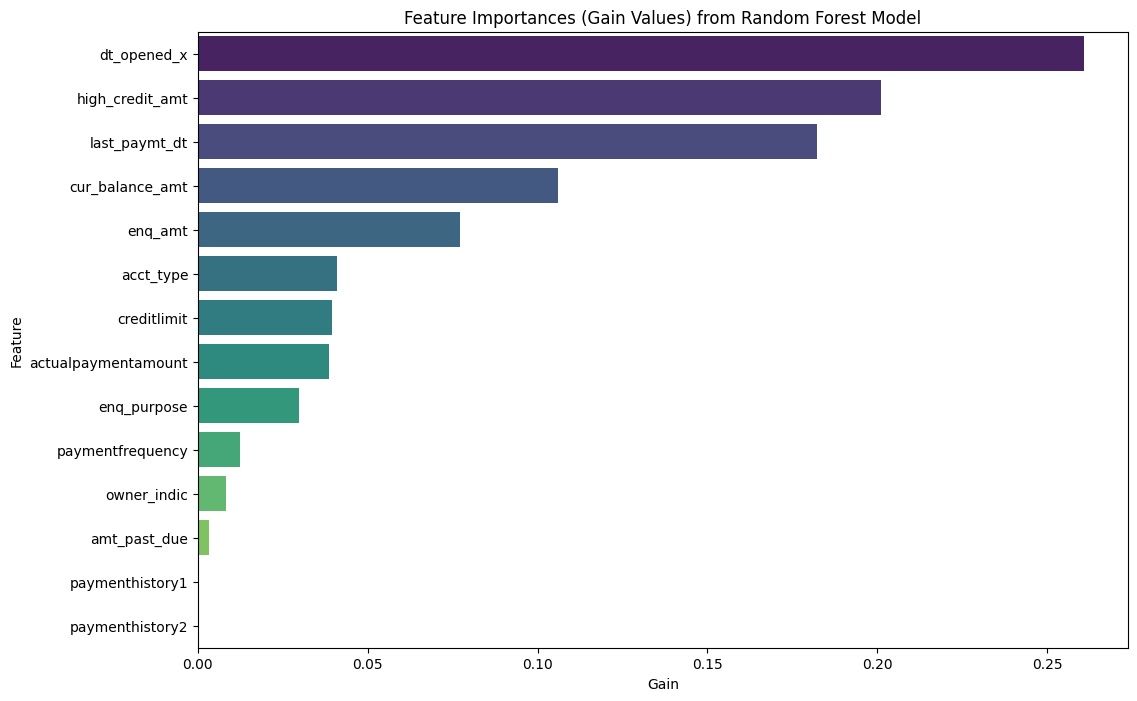

In [65]:
# Visualization of the feature importances (Gain Values)
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance_df, x='Gain', y='Feature', palette='viridis')
plt.title('Feature Importances (Gain Values) from Random Forest Model')
plt.xlabel('Gain')
plt.ylabel('Feature')
plt.show()

#### Predicted probabilities

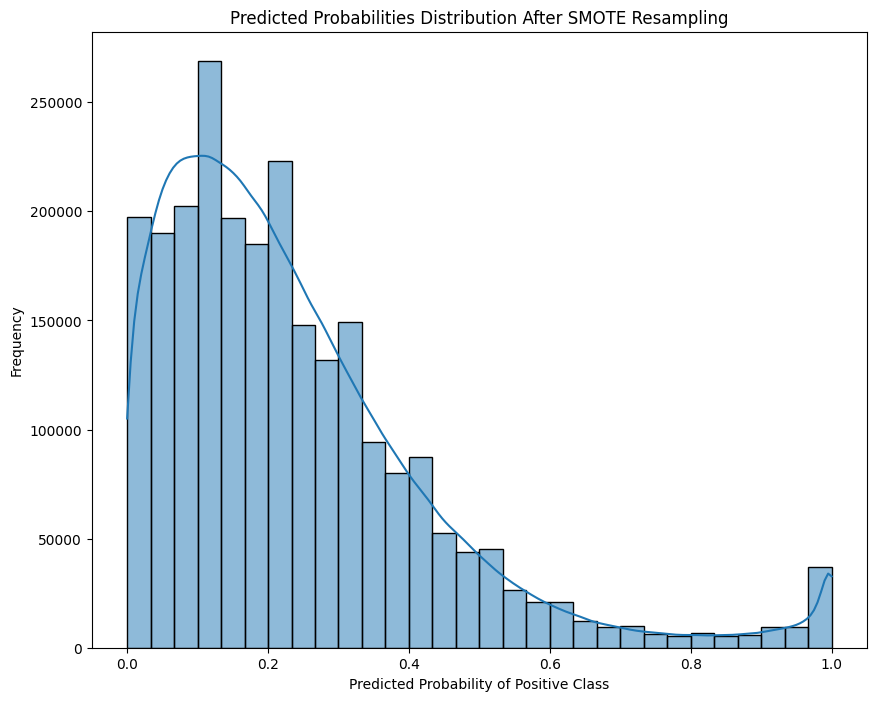

In [66]:
# Visualization of the predicted probabilities after resampling
plt.figure(figsize=(10, 8))
sns.histplot(y_pred_proba, bins=30, kde=True)  # Plotting the distribution of predicted probabilities
plt.title('Predicted Probabilities Distribution After SMOTE Resampling')
plt.xlabel('Predicted Probability of Positive Class')
plt.ylabel('Frequency')
plt.show()

### Example customer prediction

In [67]:
# Example customer data to be processed
example_customer_data = {
    'customer_no': ['SAMPLE_123'],
    'high_credit_amt': ['10000'],
    'cur_balance_amt': ['5000'],
    'amt_past_due': ['0'],
    'acct_type': ['10'],
    'owner_indic': ['1'],
    'paymenthistory1': ['Y'],
    'paymenthistory2': ['Y'],
    'paymentfrequency': ['Monthly'],
    'actualpaymentamount': ['500'],
    'dt_opened_x': ['01-Jan-2020'],
    'last_paymt_dt': ['01-Jan-2023'],
    'enq_purpose': ['New Credit'],
    'enq_amt': ['15000'],
    'Bad_label': ['0']
}

In [68]:
# Convert sample data to DataFrame
example_customer_df = pd.DataFrame(example_customer_data)

In [69]:
# Function to preprocess example customer data
def preprocess_sample_data(sample_df_raw):
    sample_df = sample_df_raw.copy()

    # Convert date columns to datetime
    for date_col in ['dt_opened_x', 'last_paymt_dt']:
        if date_col in sample_df.columns:
            sample_df[date_col] = pd.to_datetime(sample_df[date_col], errors='coerce')

    # Drop 'Bad_label' if it exists to avoid confusion
    sample_df.drop(columns=['Bad_label'], inplace=True, errors='ignore')

    # Identify object columns for encoding
    sample_object_cols_to_encode = sample_df.select_dtypes(include='object').columns.tolist()
    print("Identified Object Columns for Encoding:", sample_object_cols_to_encode)

    # Check if there are columns to encode
    if sample_object_cols_to_encode:
        encoder = OneHotEncoder(sparse_output=True, drop='first', handle_unknown='ignore')
        print("Shape of Sample Data Before Encoding:", sample_df[sample_object_cols_to_encode].shape)
        
        encoded_features = encoder.fit_transform(sample_df[sample_object_cols_to_encode])
        sample_df.drop(columns=sample_object_cols_to_encode, inplace=True, errors='ignore')
    else:
        print("No object columns found for encoding.")
        encoded_features = csr_matrix(np.empty((sample_df.shape[0], 0)))

    # Fill NaN values and convert remaining columns to numeric
    sample_df.fillna(0, inplace=True)
    sample_df = sample_df.apply(pd.to_numeric, errors='coerce')

    # Convert the numeric part to a sparse matrix
    X_sample_numeric_sparse = csr_matrix(sample_df.values)

    # Combine numeric and encoded features into a final sparse matrix
    X_sample_sparse = hstack([X_sample_numeric_sparse, encoded_features])

    # Ensure that the sparse matrix has the right shape
    if X_sample_sparse.shape[1] != model.n_features_in_:
        padded_x_sample_sparse = csr_matrix((sample_df.shape[0], model.n_features_in_))
        padded_x_sample_sparse[:, :X_sample_sparse.shape[1]] = X_sample_sparse
        return padded_x_sample_sparse

    return X_sample_sparse

In [70]:
# Function to predict credit score
def predict_credit_score(processed_data, model):
    prediction = model.predict(processed_data)
    prediction_proba = model.predict_proba(processed_data)

    cred_score_status = "Good credit history (Low risk of default)" if prediction[0] == 0 else "Bad credit history (High risk of default)"

    print(f"The predicted credit score status for the example customer is: {cred_score_status}")
    print(f"Probability of Good Credit (0): {prediction_proba[0][0]:.4f}")
    print(f"Probability of Bad Credit (1): {prediction_proba[0][1]:.4f}")

    return cred_score_status, prediction_proba

In [71]:
# Predict the credit score of example customer using the pretrained model
model = joblib.load('/kaggle/working/random_forest_model.pkl')
processed_example_data = preprocess_sample_data(example_customer_df)
status, probabilities = predict_credit_score(processed_example_data, model)

Identified Object Columns for Encoding: ['customer_no', 'high_credit_amt', 'cur_balance_amt', 'amt_past_due', 'acct_type', 'owner_indic', 'paymenthistory1', 'paymenthistory2', 'paymentfrequency', 'actualpaymentamount', 'enq_purpose', 'enq_amt']
Shape of Sample Data Before Encoding: (1, 12)
The predicted credit score status for the example customer is: Good credit history (Low risk of default)
Probability of Good Credit (0): 0.6900
Probability of Bad Credit (1): 0.3100


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.0s finished
